In [3]:
import numpy as np
import pandas as pd

In [4]:
df = pd.read_csv(r'spam.csv',encoding='latin-1')

In [5]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
4276,ham,I'm glad. You are following your dreams.,NaN,NaN,NaN
1646,ham,Thts wat Wright Brother did to fly..,NaN,NaN,NaN
4360,ham,"Don't Think About \What u Have Got\"" Think Abo...",NaN,NaN,NaN
423,spam,URGENT! Your Mobile number has been awarded wi...,NaN,NaN,NaN
5374,ham,Do u konw waht is rael FRIENDSHIP Im gving yuo...,NaN,NaN,NaN


In [6]:
df.shape

(5572, 5)

## 1.Data Cleaning


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [8]:
#drop last 3 columns
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)

In [9]:
df.sample(5)

,v1,v2
5551,ham,Wen did you get so spiritual and deep. That's ...
1418,ham,Lmao. Take a pic and send it to me.
2126,ham,You do got a shitload of diamonds though
4765,ham,Whens your radio show?
1264,ham,I will see in half an hour


In [10]:
#renaming columns
df.rename(columns={'v1':'Target','v2':'message'},inplace=True)
df.sample(5)

,Target,message
826,ham,Hahaha..use your brain dear
5284,ham,Sent me ur email id soon
5452,ham,What???? Hello wats talks email address?
129,ham,K..k:)how much does it cost?
4404,ham,Dun need to use dial up juz open da browser n ...


In [11]:
#encoding
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()

In [12]:
df['Target']=encoder.fit_transform(df['Target'])

In [13]:
df.head()

,Target,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [14]:
#missing values
df.isnull().sum()

Target     0
message    0
dtype: int64

In [15]:
# check duplicate values
df.duplicated().sum()

np.int64(403)

In [16]:
# remove duplicate
df=df.drop_duplicates(keep='first')

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df.shape

(5169, 2)

## EDA

In [19]:
import matplotlib.pyplot as plt

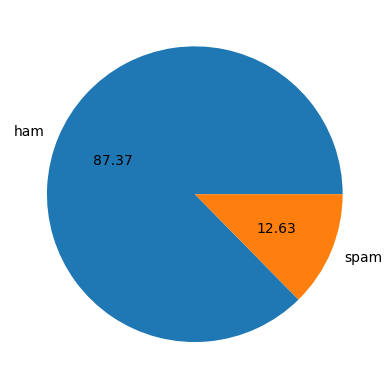

In [20]:
plt.pie(df['Target'].value_counts(),labels=['ham','spam'],autopct='%0.2f')
plt.show()

In [21]:
#data is imbalanced

In [22]:
import nltk

In [23]:
pip install nltk

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [24]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to C:\Users\Aqueel
[nltk_data]     Shaikh\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [25]:
df['num_char']=df['message'].apply(len) 

In [26]:
df['num_word']=df['message'].apply(lambda x:len(nltk.word_tokenize(x)))

In [27]:
df['num_sentence']=df['message'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [28]:
df.head()

,Target,message,num_char,num_word,num_sentence
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [29]:
df[['num_char','num_word','num_sentence']].describe()

,num_char,num_word,num_sentence
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [30]:
#ham
df[df['Target']==0][['num_char','num_word','num_sentence']].describe()

,num_char,num_word,num_sentence
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [31]:
#spam
df[df['Target']==1][['num_char','num_word','num_sentence']].describe()

,num_char,num_word,num_sentence
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [32]:
import seaborn as sns

<Axes: xlabel='num_char', ylabel='Count'>

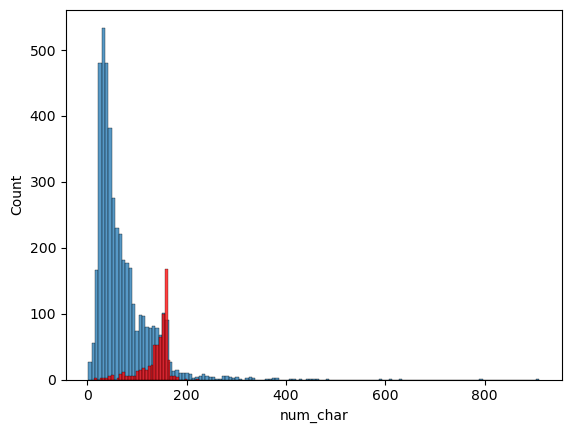

In [33]:
sns.histplot(df[df['Target']==0]['num_char'])
sns.histplot(df[df['Target']==1]['num_char'],color='red')

<Axes: xlabel='num_word', ylabel='Count'>

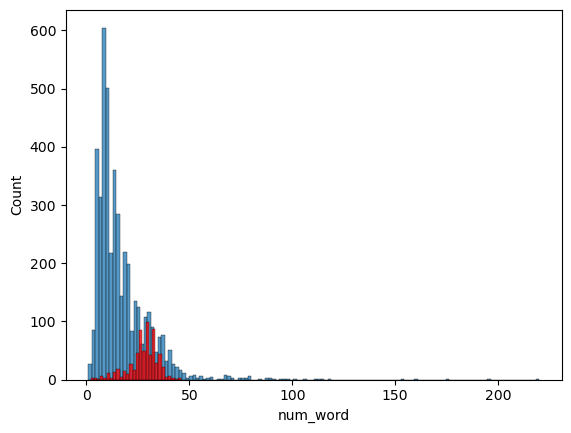

In [34]:
sns.histplot(df[df['Target']==0]['num_word'])
sns.histplot(df[df['Target']==1]['num_word'],color='red')

<Axes: xlabel='num_sentence', ylabel='Count'>

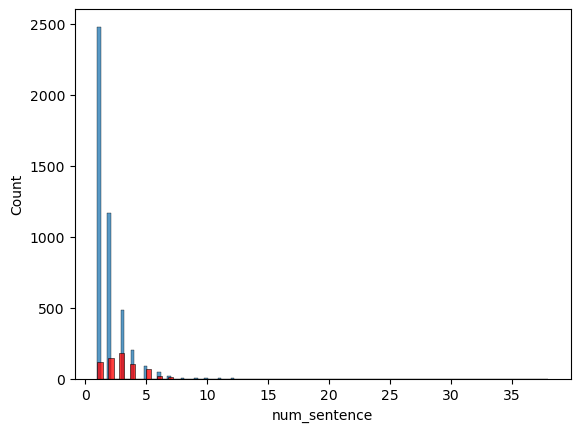

In [35]:
sns.histplot(df[df['Target']==0]['num_sentence'])
sns.histplot(df[df['Target']==1]['num_sentence'],color='red')

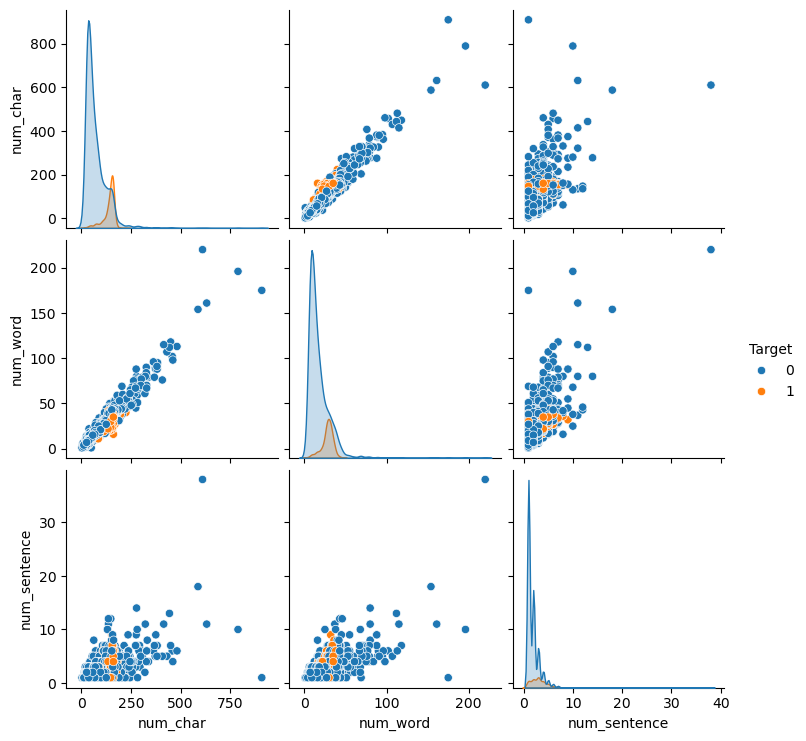

In [36]:
sns.pairplot(df,hue='Target')

<Axes: >

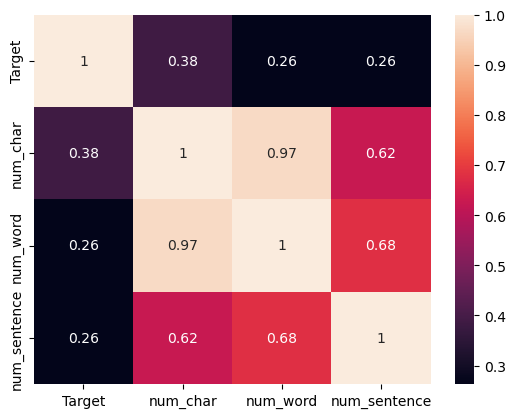

In [37]:
sns.heatmap(df.select_dtypes(include=['number']).corr(),annot=True)

## 3. Data Preprocessing

In [38]:
from nltk.corpus import stopwords
import string
from nltk.stem.porter import PorterStemmer
ps=PorterStemmer()

In [39]:
def transform_mess(message):
    message=message.lower()
    message=nltk.word_tokenize(message)

    y=[]
    for i in message:
        if i.isalnum():
            y.append(i)

    message=y[:]
    y.clear()

    for i in message:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)
            
    message=y[:]
    y.clear()

    for i in message:
        y.append(ps.stem(i))
    
    return ' '.join(y)

In [40]:
df['transformed_msg'] = df['message'].apply(transform_mess)

In [41]:
df.head()

,Target,message,num_char,num_word,num_sentence,transformed_msg
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [42]:
pip install --user wordcloud

Note: you may need to restart the kernel to use updated packages.


In [43]:
from wordcloud import WordCloud
wc= WordCloud(width=500,height=500,min_font_size=10,background_color='white')

In [44]:
spam_wc=wc.generate(df[df['Target']==1]['transformed_msg'].str.cat(sep=' '))

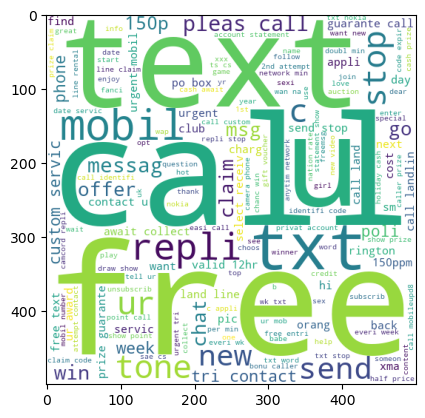

In [45]:
plt.imshow(spam_wc)

In [46]:
ham_wc=wc.generate(df[df['Target']==0]['transformed_msg'].str.cat(sep=' '))

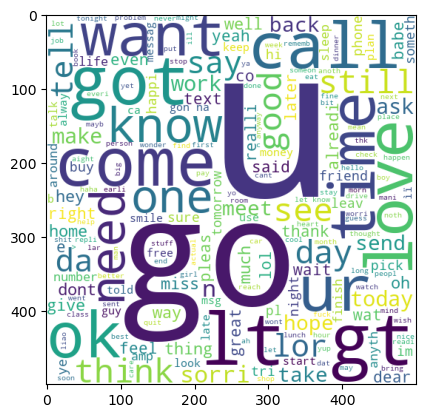

In [47]:
plt.imshow(ham_wc)

In [48]:
spam_corpus=[]
for sentence in df[df['Target']==1]['transformed_msg'].tolist():
    for word in sentence.split():
        spam_corpus.append(word)

In [49]:
len(spam_corpus)

9939

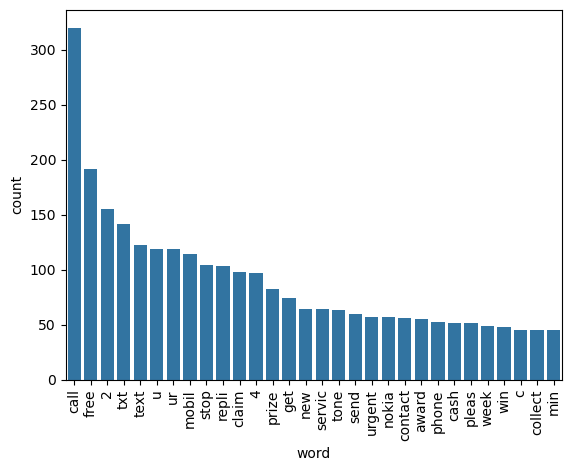

In [50]:
from collections import Counter
spam_top30_words=pd.DataFrame(Counter(spam_corpus).most_common(30), columns=['word','count'])
sns.barplot(data=spam_top30_words, x='word',y='count')
plt.xticks(rotation='vertical')
plt.show()

In [51]:
ham_corpus=[]
for sentence in df[df['Target']==0]['transformed_msg'].tolist():
    for word in sentence.split():
        ham_corpus.append(word)

In [52]:
len(ham_corpus)

35404

<function matplotlib.pyplot.show(close=None, block=None)>

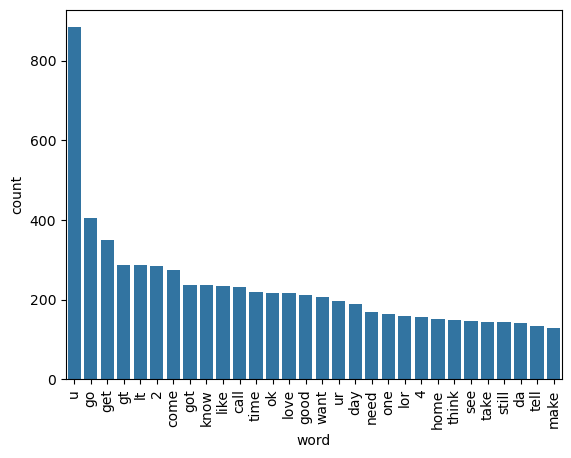

In [53]:
ham_top30_words=pd.DataFrame(Counter(ham_corpus).most_common(30),columns=['word','count'])
sns.barplot(data=ham_top30_words,x='word',y='count')
plt.xticks(rotation='vertical')
plt.show

## Modeling Building

In [54]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features=3000,ngram_range=(1,2),stop_words='english')

In [105]:
X = tfidf.fit_transform(df['transformed_msg']).toarray()

In [106]:
#from sklearn.preprocessing import MinMaxScaler
#scaler = MinMaxScaler()
#X = scaler.fit_transform(X)

In [107]:
X.shape

(5169, 3000)

In [108]:
y=df['Target'].values

In [109]:
y

array([0, 0, 1, ..., 0, 0, 0], shape=(5169,))

In [110]:
from sklearn.model_selection import train_test_split

In [111]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2 ,random_state=2)

In [112]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [113]:
gnb=GaussianNB()
mnb=MultinomialNB()
bnb=BernoulliNB()

In [114]:
gnb.fit(X_train,y_train)
y_pred1=gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.8752417794970987
[[786 110]
 [ 19 119]]
0.519650655021834


In [115]:
mnb.fit(X_train,y_train)
y_pred2=mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9758220502901354
[[896   0]
 [ 25 113]]
1.0


In [116]:
bnb.fit(X_train,y_train)
y_pred3=bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9816247582205029
[[896   0]
 [ 19 119]]
1.0


In [117]:
#tfidf -> Mnb

In [118]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

In [119]:
lrc=LogisticRegression(C=0.5, class_weight='balanced')
svm=SVC(gamma=1.0,kernel='sigmoid')
dtc=DecisionTreeClassifier(max_depth=5)
knc=KNeighborsClassifier()

In [120]:
clf={
    'svc':svm,
    'lr':lrc,
    'nb':mnb,
    'dt':dtc,
    'knn':knc
}

In [121]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred=clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    from sklearn.model_selection import cross_val_score

    scores = cross_val_score(clf, X_train, y_train, cv=5)
    print(scores.mean())

    return accuracy,precision

In [122]:
accuracy_scores = []
precision_scores = []
for names,model in clf.items():
    current_accuracy,current_precision = train_classifier(model,X_train,y_train,X_test,y_test)

    print('For',names)
    print('Accuracy',current_accuracy)
    print('Precision',current_precision)

    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

0.9746070133010882
For svc
Accuracy 0.9796905222437138
Precision 0.975609756097561
0.9683192261185006
For lr
Accuracy 0.9748549323017408
Precision 0.917910447761194
0.9683192261185006
For nb
Accuracy 0.9758220502901354
Precision 1.0
0.9363966142684401
For dt
Accuracy 0.9313346228239845
Precision 0.8526315789473684
0.9037484885126965
For knn
Accuracy 0.9052224371373307
Precision 1.0


In [123]:
print(accuracy_scores,precision_scores)

[0.9796905222437138, 0.9748549323017408, 0.9758220502901354, 0.9313346228239845, 0.9052224371373307] [0.975609756097561, 0.917910447761194, 1.0, 0.8526315789473684, 1.0]


In [124]:
performance_df=pd.DataFrame({'Algorithm':clf.keys(),
                             'Accuracy':accuracy_scores,
                             'Precision':precision_scores}).sort_values('Precision',ascending=False)

In [125]:
performance_df

,Algorithm,Accuracy,Precision
2,nb,0.975822,1.000000
4,knn,0.905222,1.000000
0,svc,0.979691,0.975610
1,lr,0.974855,0.917910
3,dt,0.931335,0.852632


In [101]:
temp_df = pd.DataFrame({'Algorithm':clf.keys(),
                        'Accuracy_scaling':accuracy_scores,
                        'Precision_scaling':precision_scores}).sort_values('Precision_scaling',ascending=False)

In [126]:
new_df_scaled = performance_df.merge(temp_df,on='Algorithm')

In [127]:
new_df_scaled

,Algorithm,Accuracy,Precision,Accuracy_scaling,Precision_scaling
0,nb,0.975822,1.000000,0.981625,0.983740
1,knn,0.905222,1.000000,0.905222,1.000000
2,svc,0.979691,0.975610,0.974855,0.951613
3,lr,0.974855,0.917910,0.981625,0.968504
4,dt,0.931335,0.852632,0.930368,0.843750


In [128]:
import pickle
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(mnb,open('model.pkl','wb'))